# Decision Tree 

In [2]:
import math

In [3]:
# Example Dataset
# Let's say we have a dataset with two classes, A and B
# Suppose in a dataset of 10 elements, 4 are of class A and 6 are of class B

# Number of elements in each class
n_A = 4
n_B = 6
total = n_A + n_B

In [4]:
# find the proportions 
p_A = n_A/total
p_B = n_B/total

# print the proportions 
print(f"Proportion of A : {p_A}")
print(f"Proportion of B : {p_B}")

Proportion of A : 0.4
Proportion of B : 0.6


In [5]:
# entropy calculate 
# entropy is the uncertainty or disorder 

entropy = -p_A * math.log2(p_A) - p_B * math.log2(p_B)
print(f"Entropy is : {entropy:.4f}")

Entropy is : 0.9710


In [6]:
# gini impurity calculate 

gini = 1- p_A**2 - p_B**2
print(f"Gini impurity is : {gini:.4f}")

Gini impurity is : 0.4800


---
# Decision Tree Classifier 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer 

In [8]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [9]:
# drop the deck column
df.drop(columns=['deck'],inplace=True)
# impute missing values in age and fare using median imputer 
imputer = SimpleImputer(strategy='median')
df[['age','fare']] = imputer.fit_transform(df[['age','fare']])

# impute embark and embarked_town with mode
imputer = SimpleImputer(strategy='most_frequent')
df[['embarked','embark_town']] = imputer.fit_transform(df[['embarked','embark_town']])

# encode using for loop and le
for col in df.select_dtypes(include=['category','object']):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,2,1,True,2,0,False
1,1,1,0,38.0,1,0,71.2833,0,0,2,False,0,1,False
2,1,3,0,26.0,0,0,7.9250,2,2,2,False,2,1,True
3,1,1,0,35.0,1,0,53.1000,2,0,2,False,2,1,False
4,0,3,1,35.0,0,0,8.0500,2,2,1,True,2,0,True


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       105
           1       1.00      1.00      1.00        74

    accuracy                           1.00       179
   macro avg       1.00      1.00      1.00       179
weighted avg       1.00      1.00      1.00       179



<Axes: >

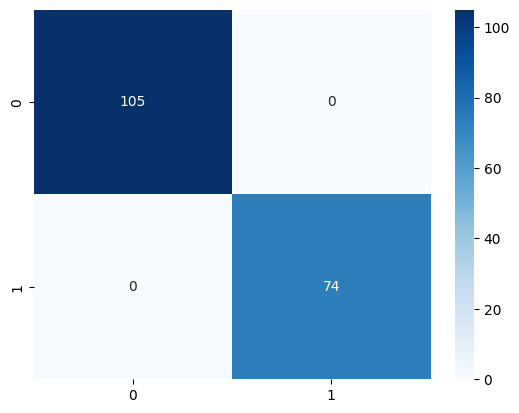

In [10]:
# 1.Define X and y 
X = df.drop('survived',axis=1)
y = df['survived']

# 2. train test split 
X_train , X_test , y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# 3. fit the model 
model = DecisionTreeClassifier(criterion='entropy',random_state=42)
model.fit(X_train,y_train)

# 4. predict
y_pred = model.predict(X_test)
print(classification_report(y_test,y_pred))
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,cmap='Blues',fmt='d')

In [11]:
# save the DT
from sklearn.tree import export_graphviz
export_graphviz(model,out_file='./saved_models/DecisionTree.dot',feature_names=X.columns,filled=True,rounded=True)